In [258]:
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [259]:
# belt_path = './grace-7312025/belt/*.csv'
# sensor_path = './grace-7312025/sensor/*.csv'

# belt_csvs = glob.glob(belt_path)
# sensor_csvs = glob.glob(sensor_path)

belt_csvs = ['./final-trials/belt/grace6-belt.csv','./final-trials/belt/grace9-belt.csv','./final-trials/belt/grace12-belt.csv',
             './final-trials/belt/default6-belt.csv','./final-trials/belt/default9-belt.csv','./final-trials/belt/default12-belt.csv',
             './final-trials/belt/sam6-belt.csv','./final-trials/belt/sam9-belt.csv','./final-trials/belt/sam12-belt.csv']
sensor_csvs = ['./final-trials/sensor/grace6-sensor.csv','./final-trials/sensor/grace9-sensor.csv','./final-trials/sensor/grace12-sensor.csv',
             './final-trials/sensor/default6-sensor.csv','./final-trials/sensor/default9-sensor.csv','./final-trials/sensor/default12-sensor.csv',
             './final-trials/sensor/sam6-sensor.csv','./final-trials/sensor/sam9-sensor.csv','./final-trials/sensor/sam12-sensor.csv']

In [266]:
belt_df_list = [pd.read_csv(path) for path in belt_csvs]
sensor_df_list = [pd.read_csv(path) for path in sensor_csvs]

# delete extra columns for outside data analysis
for df in sensor_df_list:
    if len(df.columns) == 3:
        print(df.head())
        df = df.drop(columns=["Breath Motion"], axis=1)

for i in range(len(sensor_df_list)):
    # initial data cleaning
    to_subtract = sensor_df_list[i].iloc[0,0]
    sensor_df_list[i].rename(columns = {'Timestamp':'Time', 'Breath Rate':'sensor-bpm'}, inplace=True)
    sensor_df_list[i]['Time'] = sensor_df_list[i]['Time'] - to_subtract
    sensor_df_list[i]['Time'] = np.floor(sensor_df_list[i]['Time']/10)*10
    

    # group data by time and use average breath rate
    sensor_df_list[i] = sensor_df_list[i].groupby('Time', as_index=False)['sensor-bpm'].mean()
    time_drop_condition = sensor_df_list[i]["Time"] <= 300
    sensor_df_list[i] = sensor_df_list[i][time_drop_condition]
    # print(sensor_df_list[i].tail())

    # add additional columns to keep track of data
    sensor_df_list[i].insert(loc = 0, column = 'Height', value = f"{i+1}")
    sensor_df_list[i].insert(loc = 1, column="Position", value = "Front")
    sensor_df_list[i].insert(loc=2, column="Distance (m)", value = 0.6)

    # process belt data
    belt_df_list[i].dropna(inplace = True)
    




belt_df = pd.concat(belt_df_list, ignore_index=True)
sensor_df = pd.concat(sensor_df_list, ignore_index=True)


# account for the occasional sensor cutoffs
for i in range(0,300,10):
    if i not in sensor_df['Time'].values:
        belt_drop_condition = belt_df["Time"] == i
        belt_df = belt_df[belt_drop_condition]


sensor_df.insert(4, 'bpm', belt_df['bpm'])
# sensor_df['bpm'] = belt_df['bpm']


In [267]:
# dataframe we will work with for data analysis - no more need for timestamps
df = sensor_df
# df.pop(df.columns[3])

# # prep sam's data + merge
# sam_df = pd.read_csv('./cleanBreathData.csv')

# sam_df.pop(sam_df.columns[0])
# sam_df.pop(sam_df.columns[-1])
# sam_df.pop(sam_df.columns[-1])

# sam_df.rename(columns={'height': 'Height', 'position': 'Position', 'breathingBeltRespiration': 'bpm', 'sensorRespiration':'sensor-bpm'}, inplace=True)

# sam_df.insert(loc=2, column="Distance (m)", value = 0.6)

# df = pd.concat([df,sam_df])
# print(df.head())
# print(df.tail())

In [268]:
# add deviation + percent error
df['deviation'] = df['sensor-bpm'] - df['bpm']
df['percent-error'] = (df['sensor-bpm'] - df['bpm'])/df['bpm']

# clean zeroes 
df = df[df['bpm'] != 0]

# save to csv
df.to_csv("./final-trials/cleaned.csv", index=False)

In [269]:
# print average percent error
error_sum = 0
entry_count = 0
for error in df["percent-error"]:
    error_sum += abs(error)
    entry_count += 1
print(f"mean % error:\t{error_sum/entry_count}")

avg_real_error = 0
for error in df["deviation"]:
    avg_real_error += abs(error)

print(f"mean real error: {avg_real_error/entry_count}")

# get other averages
avg_breathing_belt = 0
avg_sensor_rate = 0
for bpm in df['bpm']:
    avg_breathing_belt += bpm
for sensor_bpm in df['sensor-bpm']:
    avg_sensor_rate+=sensor_bpm

avg_breathing_belt /= entry_count
avg_sensor_rate /= entry_count

mean % error:	0.5618485369735886
mean real error: 5.044964876883327


In [270]:
# correlation tests
x1 = np.array(df['bpm'].to_list())
x2 = np.array(df['sensor-bpm'].to_list())

res=stats.kendalltau(x1,x2)
tau_val = res.statistic
p_val = res.pvalue

print("KENDALL CORRELATION TEST")
print(f"\ttau: {tau_val}")
# print(f"\tp: {p_val}")

res=stats.spearmanr(x1,x2)
spearman_val = res.statistic
p_val = res.pvalue

print("SPEARMAN CORRELATION TEST")
print(f"\tstatistic: {spearman_val}")
# print(f"\tp: {p_val}")

KENDALL CORRELATION TEST
	tau: 0.2892561978366425
SPEARMAN CORRELATION TEST
	statistic: 0.37869154638976027


Slope (m): 1.3825094132327902
Intercept (c): 0.0
r-squared: 0.14652988574970316


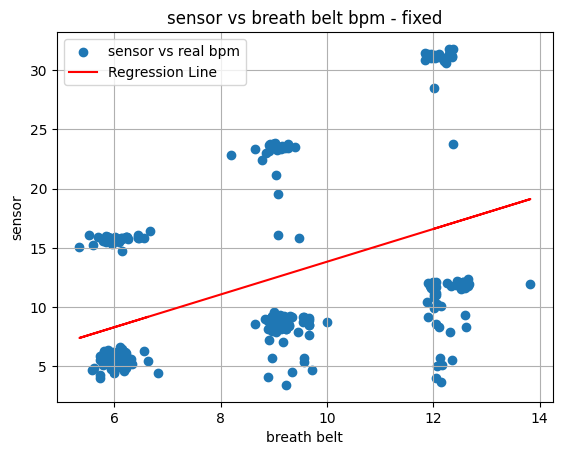

In [271]:
# fixed at 0
from sklearn import linear_model

x = np.array(df['bpm'].to_list())
y = np.array(df['sensor-bpm'].to_list())


model = linear_model.LinearRegression(fit_intercept=False)

model.fit(x.reshape(-1,1),y)
slope = model.coef_[0]
intercept = model.intercept_
r_sqaured = model.score(x.reshape(-1,1),y)

print(f"Slope (m): {slope}")
print(f"Intercept (c): {intercept}")
print(f"r-squared: {r_sqaured}")

# Generate predicted y values for plotting the regression line
y_predicted = slope * x + intercept

# Plotting the results
plt.scatter(x, y, label='sensor vs real bpm')
plt.plot(x, y_predicted, color='red', label='Regression Line')
plt.xlabel('breath belt')
plt.ylabel('sensor')
plt.title('sensor vs breath belt bpm - fixed')
plt.legend()
plt.grid(True)
plt.show()


Slope (m): 1.2132633902745737
Intercept (c): 1.663356150901235
r-squared: 0.14966806441076064


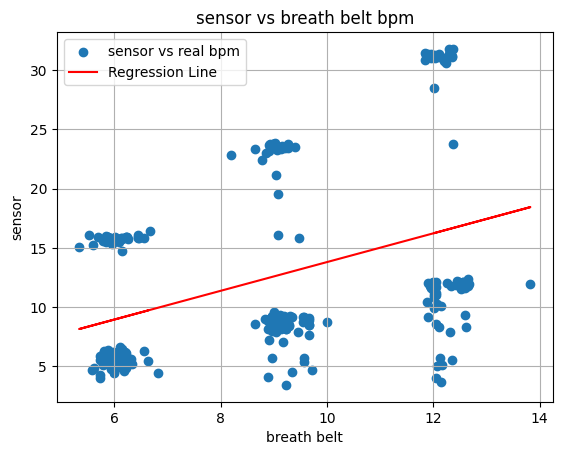

In [272]:
# not fixed at 0
model = linear_model.LinearRegression()

model.fit(x.reshape(-1,1),y)
slope = model.coef_[0]
intercept = model.intercept_
r_sqaured = model.score(x.reshape(-1,1),y)

print(f"Slope (m): {slope}")
print(f"Intercept (c): {intercept}")
print(f"r-squared: {r_sqaured}")

# Generate predicted y values for plotting the regression line
y_predicted = slope * x + intercept

# Plotting the results
plt.scatter(x, y, label='sensor vs real bpm')
plt.plot(x, y_predicted, color='red', label='Regression Line')
plt.xlabel('breath belt')
plt.ylabel('sensor')
plt.title('sensor vs breath belt bpm')
plt.legend()
plt.grid(True)
plt.show()

In [273]:
# calculate r^2 value
ssr = 0
sst = 0